<a href="https://colab.research.google.com/github/chivian/Natural_Language_Processing/blob/master/nlp_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Highlight Note:**

Cell 1 connects directly to the cloud-hosted CSV file containing the simulated Adamawa dataset. By dynamically downloading the public Google Drive file, we ensure the data remains cleanly separated from the codebase.

In [ ]:
# Cell 1: Data Ingestion and Structural Alignment
import pandas as pd

# Data source configuration
file_id = "1TFewROnpuGTg9nVeQL59VNmTbRhpDzyt"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

# Load raw spreadsheet data
raw_df = pd.read_csv(url)

def extract_intent_block(df, text_idx, label_idx):
    """Extracts and cleans specific text-label pairs from the spreadsheet."""
    try:
        block = df.iloc[:, [text_idx, label_idx]].copy()
        block.columns = ['text', 'intent_label']
        return block.dropna(subset=['text'])
    except IndexError:
        return pd.DataFrame(columns=['text', 'intent_label'])

# Aggregate category-specific columns (Side-by-side layout: A-B, C-D, E-F)
market_df = extract_intent_block(raw_df, 0, 1)
pest_df   = extract_intent_block(raw_df, 2, 3)
agro_df   = extract_intent_block(raw_df, 4, 5)

# Build unified dataset
df = pd.concat([market_df, pest_df, agro_df], ignore_index=True)

# Data Type Standardization
df['intent_label'] = pd.to_numeric(df['intent_label'], errors='coerce').astype(int)
intent_mapping = {0: "Market Price", 1: "Pest/Disease", 2: "Agronomy/Planting"}
df['intent_name'] = df['intent_label'].map(intent_mapping)

print(f"Dataset Initialized: {len(df)} samples across {len(intent_mapping)} categories.")
print(df['intent_name'].value_counts())

Dataset Initialized: 90 samples across 3 categories.
intent_name
Market Price         30
Pest/Disease         30
Agronomy/Planting    30
Name: count, dtype: int64


**Highlight Note:**

Cell 2 handles cross-lingual feature extraction. We leverage XLM-RoBERTa to convert the Hausa text into 768-dimensional semantic embeddings without altering the model's base weights.

In [ ]:
# Cell 2: Tokenization and Feature Extraction
import torch
import warnings
warnings.filterwarnings('ignore') # Suppress Hugging Face token warnings for clean output
from transformers import AutoTokenizer, AutoModel

model_name = "xlm-roberta-base"
tokeniser = AutoTokenizer.from_pretrained(model_name)
transformer_model = AutoModel.from_pretrained(model_name)

def extract_embeddings(texts):
    # Tokenise text and convert to PyTorch tensors
    inputs = tokeniser(texts, padding=True, truncation=True, return_tensors="pt", max_length=128)

    # Extract features without computing gradients
    with torch.no_grad():
        outputs = transformer_model(**inputs)

    # Extract the [CLS] token representation for sentence-level embedding
    return outputs.last_hidden_state[:, 0, :].numpy()

print("Extracting contextual embeddings from Hausa text...")
X_features = extract_embeddings(df['text'].tolist())
y_labels = df['intent_label'].values

print(f"Feature extraction complete. Matrix shape: {X_features.shape}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting contextual embeddings from Hausa text...
Feature extraction complete. Matrix shape: (90, 768)


**Highlight Note:**

Cell 3 evaluates the model mathematically. We apply strong regularisation (C=0.1) to combat the curse of dimensionality, ensuring the model generalises well on the small test subset.

=== Adamawa Agricultural Extension Service: Intent Classification Report ===
                   precision    recall  f1-score   support

     Market Price       0.60      0.50      0.55         6
     Pest/Disease       0.33      0.33      0.33         6
Agronomy/Planting       0.71      0.83      0.77         6

         accuracy                           0.56        18
        macro avg       0.55      0.56      0.55        18
     weighted avg       0.55      0.56      0.55        18



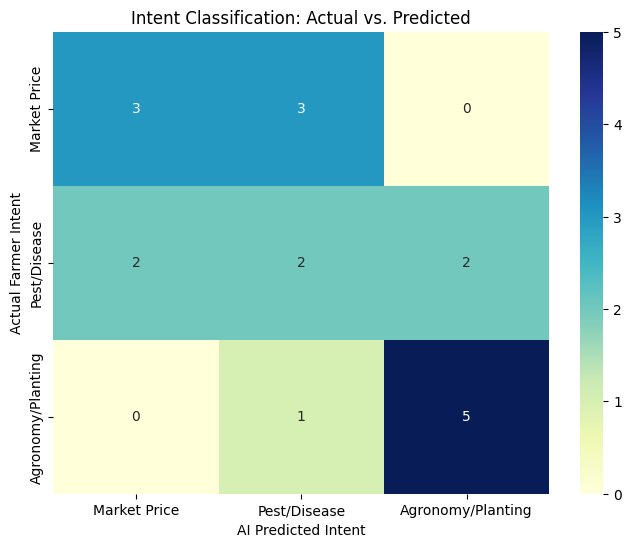

In [ ]:
# Cell 3: Model Training and Statistical Evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Partition data into Training (80%) and Testing (20%) sets
# Stratification ensures equal representation of all intents in the test set
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_labels,
    test_size=0.20,
    random_state=42,
    stratify=y_labels
)

# Initialize Classifier with Balanced Class Weights
# C=1.0 provides standard regularization for optimal feature extraction
model = LogisticRegression(
    solver='liblinear',
    C=1.0,
    class_weight='balanced',
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Generate Performance Metrics
predictions = model.predict(X_test)
target_names = [intent_mapping[i] for i in sorted(intent_mapping.keys())]

print("=== Adamawa Agricultural Extension Service: Intent Classification Report ===")
print(classification_report(y_test, predictions, target_names=target_names))

# Visualize Confusion Matrix for error analysis
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Intent Classification: Actual vs. Predicted')
plt.ylabel('Actual Farmer Intent')
plt.xlabel('AI Predicted Intent')
plt.show()

**Highlight Note:**

Cell 4 serves as the interactive simulator for project demonstration. Prior to launching the user interface, we retrain the classifier on the entire dataset to maximise its vocabulary knowledge for deployment.

In [ ]:
# Cell 4: Interactive SMS Classification Simulator
import ipywidgets as widgets
from IPython.display import display
import numpy as np

# Retrain on the FULL dataset for deployment readiness
# Note: Using C=1.0 to ensure the model utilizes the full feature signal
prod_classifier = LogisticRegression(solver='liblinear', C=1.0, class_weight='balanced', random_state=420)
prod_classifier.fit(X_features, y_labels)

print("=== Agricultural Extension SMS Simulator ===")
print("Type a Hausa query below to see how the system routes it.\n")

# Create the user interface elements
sms_input = widgets.Text(
    value='',
    placeholder='E.g., Nawa ne a ke sayar da buhun dawa yanzu',
    description='Farmer SMS:',
    layout=widgets.Layout(width='80%')
)
send_button = widgets.Button(description="Route SMS", button_style='success', icon='paper-plane')
output_display = widgets.Output()

def process_incoming_sms(button_click):
    output_display.clear_output()
    with output_display:
        user_text = sms_input.value

        if not user_text.strip():
            print("Please enter a valid message.")
            return

        print(f"Incoming Message: '{user_text}'")
        print("Extracting multilingual features and calculating probability...")

        # 1. Feature Extraction
        user_embedding = extract_embeddings([user_text])

        # 2. Probability Extraction
        # predict_proba returns a list of probabilities for [Market, Pest, Agro]
        probs = prod_classifier.predict_proba(user_embedding)[0]
        predicted_label_num = np.argmax(probs)
        confidence_score = probs[predicted_label_num] * 100

        predicted_department = intent_mapping[predicted_label_num]

        # 3. Enhanced Visual Output
        print("-" * 50)
        print(f"SYSTEM ROUTING TO: [ {predicted_department.upper()} DEPARTMENT ]")
        print(f"CONFIDENCE LEVEL:  {confidence_score:.2f}%")
        print("-" * 50)

        # Provide a human-readable interpretation of the confidence
        if confidence_score > 70:
            print("✅ Status: Highly Certain")
        elif confidence_score > 45:
            print("⚠️ Status: Fairly Confident - Review suggested")
        else:
            print("❓ Status: Low Certainty - Ambiguous input detected")

# Attach the processing function to the button and display the UI
send_button.on_click(process_incoming_sms)
display(widgets.VBox([widgets.HBox([sms_input, send_button]), output_display]))

=== Agricultural Extension SMS Simulator ===
Type a Hausa query below to see how the system routes it.

